In [1]:
import math
import time
from contextlib import contextmanager
from typing import Self

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn import metrics, preprocessing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", 10000)
pd.set_option("display.float_format", "{:.2f}".format)

### Первичный анализ

In [2]:
df = pd.read_csv("data/mushrooms.csv")

display(df.head(3))
display(df.info())
display(df.describe())

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface:%3F,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
0,b'j',b'i',b'a',b'a',b'x',b's',b'n',b'f',b'e',b'p',b'w',b'o',b's',b'u',b'p'
1,b'm',b'g',b'f',b'c',b'x',b's',b'y',b'f',b'e',b'p',b'w',b'o',b'n',b'g',b'e'
2,b'm',b'c',b'e',b'a',b'b',b's',b'w',b'f',b'e',b'p',b'w',b'o',b'n',b'm',b'e'


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cap-texture       8124 non-null   object
 1   spore-pattern     8124 non-null   object
 2   stem-flexibility  8124 non-null   object
 3   ring-thickness    8124 non-null   object
 4   cap-shape         8124 non-null   object
 5   cap-surface:%3F   8124 non-null   object
 6   cap-color         8124 non-null   object
 7   gill-attachment   8124 non-null   object
 8   stalk-shape       8124 non-null   object
 9   veil-type         8124 non-null   object
 10  veil-color        8124 non-null   object
 11  ring-number       8124 non-null   object
 12  population        8124 non-null   object
 13  habitat           8124 non-null   object
 14  class             8124 non-null   object
dtypes: object(15)
memory usage: 952.2+ KB


None

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface:%3F,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,19,15,10,3,6,4,10,2,2,1,4,4,6,7,2
top,b'a',b'o',b'i',b'c',b'x',b'y',b'n',b'f',b't',b'p',b'w',b'o',b'v',b'd',b'e'
freq,435,548,820,2723,3656,3244,2284,7914,4608,8124,7924,7487,4040,3148,4208


In [3]:
df = df.rename(columns={"cap-surface:%3F": "cap-surface"})

PATTERN = r"^b'|'$"

for col in df.columns:
    df[col] = df[col].str.replace(PATTERN, "", regex=True)
    df[col] = df[col].astype("category")

df.head()

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
0,j,i,a,a,x,s,n,f,e,p,w,o,s,u,p
1,m,g,f,c,x,s,y,f,e,p,w,o,n,g,e
2,m,c,e,a,b,s,w,f,e,p,w,o,n,m,e
3,e,i,j,b,x,y,w,f,e,p,w,o,s,u,p
4,b,i,h,b,x,s,g,f,t,p,w,o,a,g,e


In [4]:
print(f"Всего строк: {len(df)}")
print(f"Уникальных строк: {len(df.drop_duplicates())}")
print(f"Дубликатов: {df.duplicated().sum()}")

df = df.drop_duplicates()

print("\nСтрок с пропущенными значениями:")
print(df.isna().sum())

Всего строк: 8124
Уникальных строк: 8124
Дубликатов: 0

Строк с пропущенными значениями:
cap-texture         0
spore-pattern       0
stem-flexibility    0
ring-thickness      0
cap-shape           0
cap-surface         0
cap-color           0
gill-attachment     0
stalk-shape         0
veil-type           0
veil-color          0
ring-number         0
population          0
habitat             0
class               0
dtype: int64


**Вывод:**  
- после замены файла с данными, пропуски исчезли (до этого было ~95% от общего объема), пропущенных значений так же нет
- все признаки являются категориями
- колонка `cap-surface` имела странное название - исправлено
- убраны лишние символы во всех данных

### Анализ категориальных признаков

Уникальных категорий: 19
cap-texture
a    435
m    433
n    432
h    431
s    431
l    429
b    429
q    429
p    428
i    428
k    427
f    427
c    426
e    426
j    425
o    425
r    425
g    423
d    415
Name: count, dtype: int64
Уникальных категорий: 15
spore-pattern
o    548
h    547
l    546
g    545
d    545
i    542
k    542
m    541
a    540
b    540
c    540
n    539
f    539
j    537
e    533
Name: count, dtype: int64
Уникальных категорий: 10
stem-flexibility
i    820
j    818
e    817
b    816
d    816
g    812
f    811
a    806
c    804
h    804
Name: count, dtype: int64
Уникальных категорий: 3
ring-thickness
c    2723
a    2711
b    2690
Name: count, dtype: int64
Уникальных категорий: 6
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
Уникальных категорий: 4
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
Уникальных категорий: 10
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     

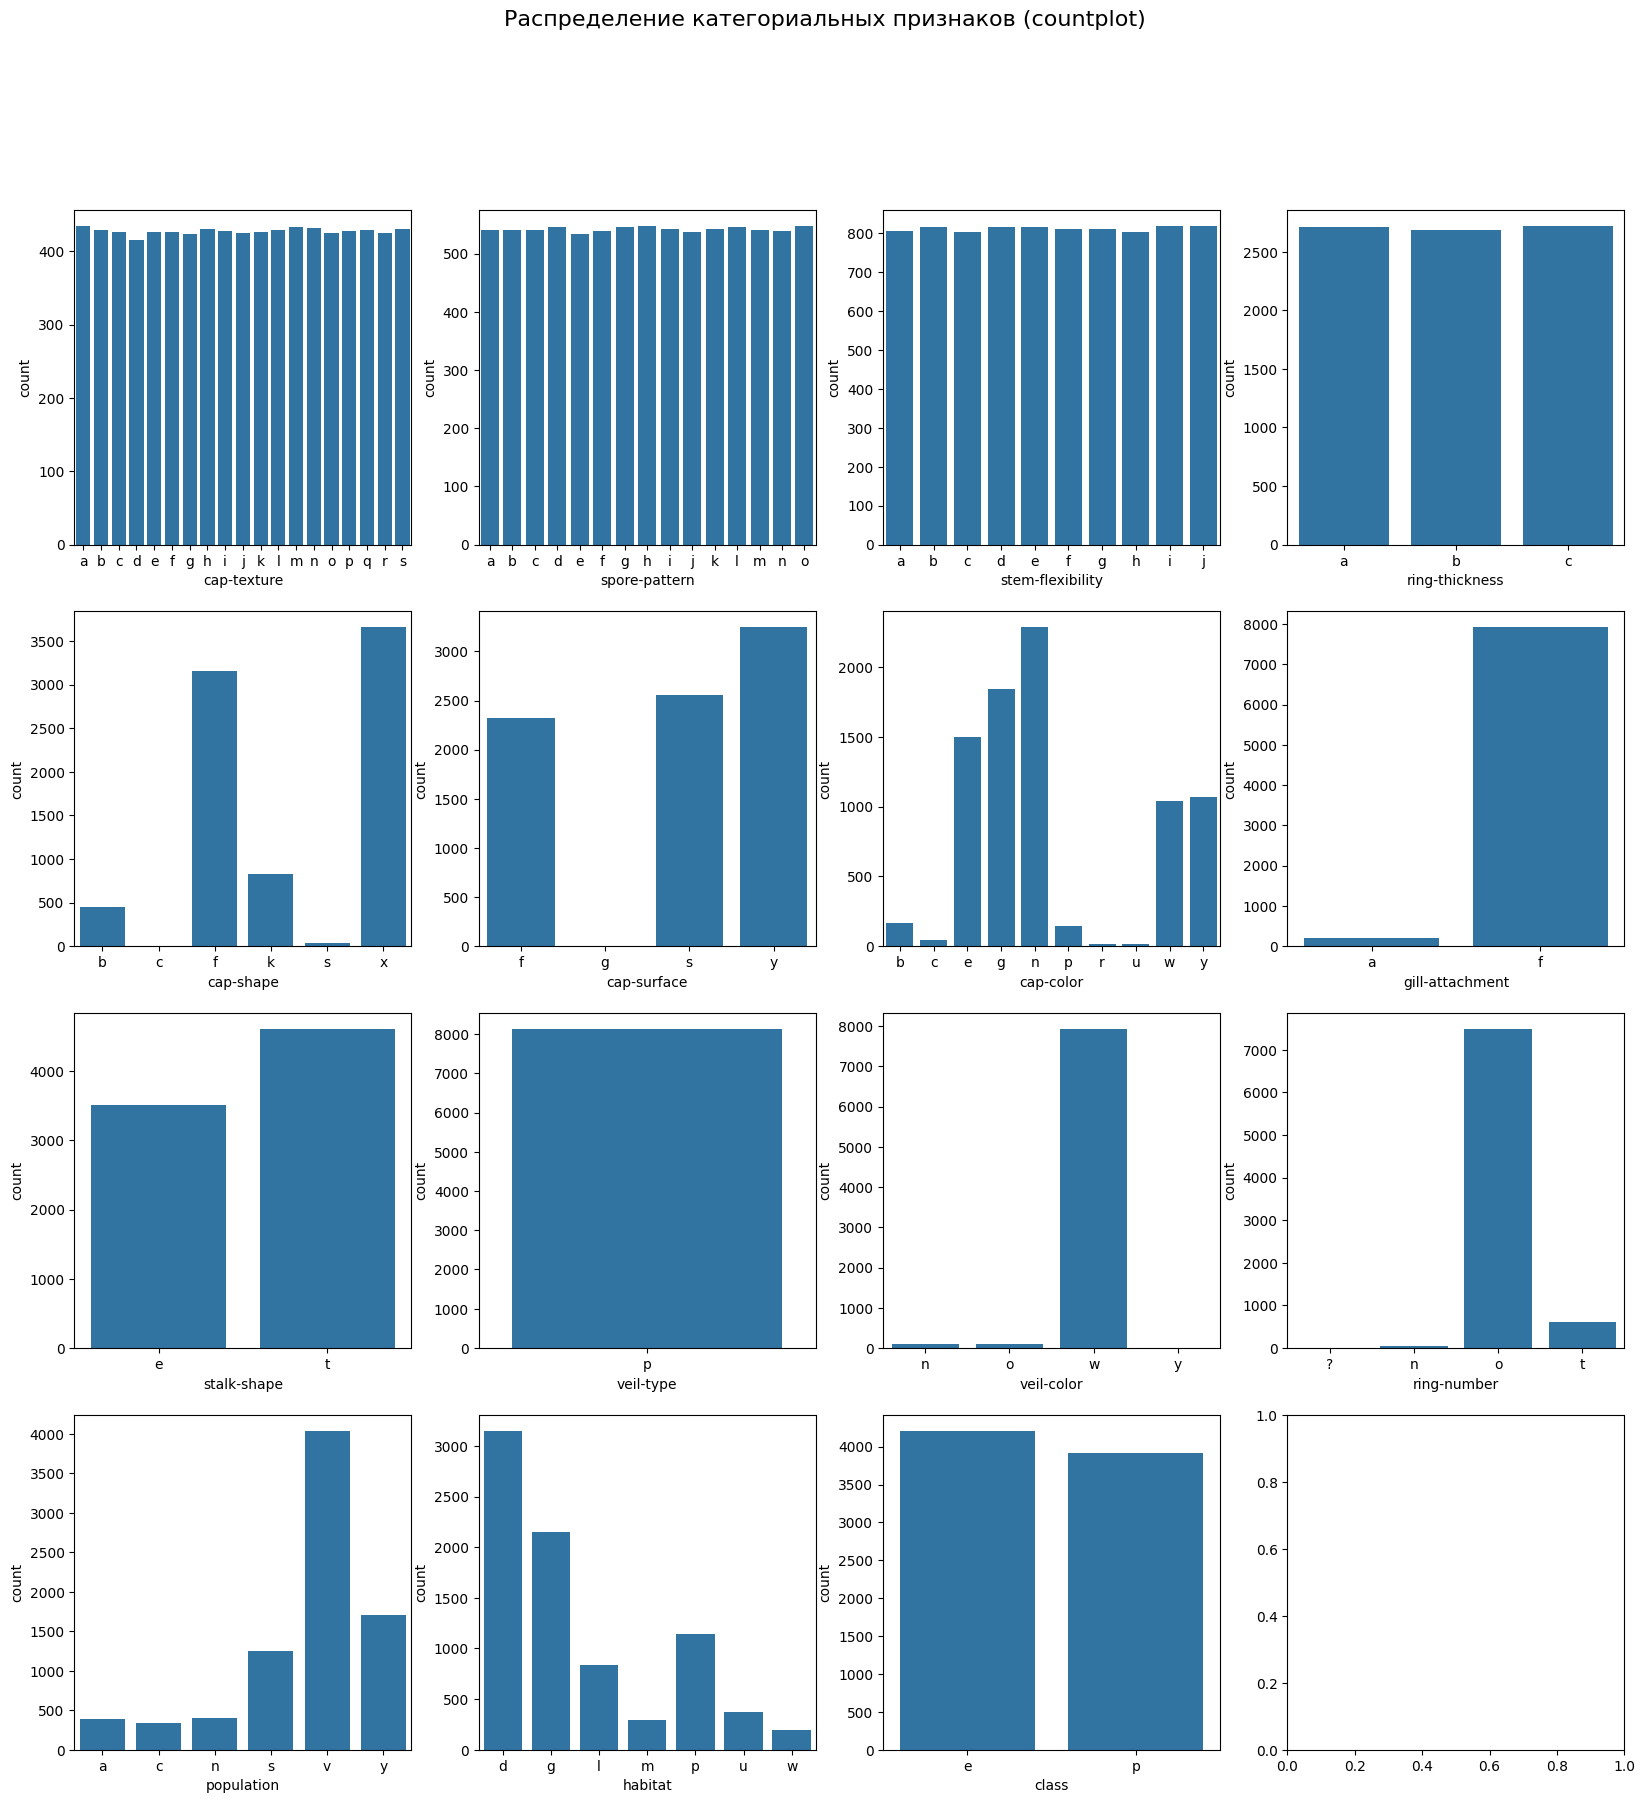

In [5]:
df_cols = df.columns
n_cols = len(df_cols)
rows = math.ceil(n_cols / 4)

fig, axes = plt.subplots(rows, 4, figsize=(20, 5*rows))
fig.suptitle("Распределение категориальных признаков (countplot)", fontsize=16)

axes = axes.flatten()

for idx, col in enumerate(df_cols):
    print("Уникальных категорий:", df[col].nunique())
    print(df[col].value_counts())
    
    ax = axes[idx]
    sns.countplot(data=df, x=col, ax=ax)

In [6]:
df = df.drop(columns=["veil-type"])

df = df[~(df["ring-number"] == "?")]
df["ring-number"] = df["ring-number"].cat.remove_categories(["?"])

counts = df["class"].value_counts(normalize=True)

print(
    "Баланс между классами:\n"
    f"Съедобные: {counts["e"]:.2f},  ядовитые: {counts["p"]:.2f}"
)

Баланс между классами:
Съедобные: 0.52,  ядовитые: 0.48


**Вывод:**  
- `veil-type` является неинформативным признаком, так представлен всего одной категорией; так же, в признаке `ring-number` имеется категория `?`, которую можно объединить с `n - нет колец` или удалить будто это Nan
- в признаках `cap-shape`, `cap-color`, `veil-color`, где две и более категории имеют малое представление, можно объединить в общую категорию
- дисбаланса между классами практически нет: деление близкое к 50/50 `(52/48)`

### Корреляция признаков

In [7]:
encoder = preprocessing.OrdinalEncoder(
    categories=[df[col].unique().tolist() for col in df.columns],
    dtype=int,
)

df_encoded = encoder.fit_transform(df)

<Axes: >

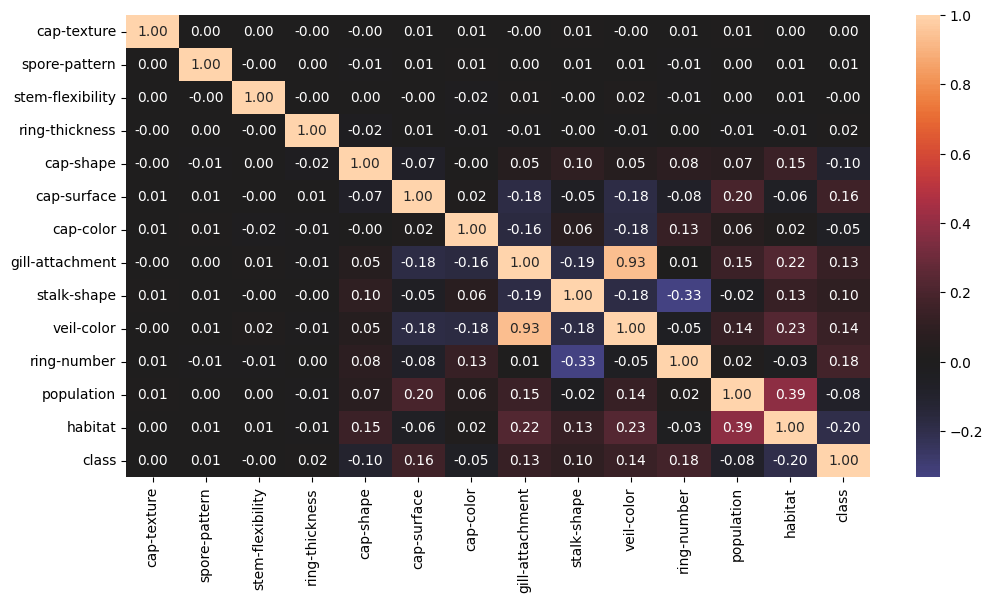

In [8]:
df_enc = pd.DataFrame(df_encoded, columns=df.columns)
corr_mat = df_enc.corr("kendall")

plt.figure(figsize=(12, 6))

sns.heatmap(corr_mat, center=0.0, annot=True, fmt=".2f")

**Вывод:**  
- наибольшую корреляцию, в первом приближении, с целевой переменной `class` имеет признак `habbit (-0.20)`, но это слабая связь как и у всех остальных признаков: `от -0.08 до 0.18`
- `cap-texture`, `spore-pattern`, `steam-flexibility` и `ring-thickness` оказывают околонулевое воздействие 
- признаки `gill-attachment` и `veil-color` имеют сильную взаимную корреляцию `0.93`, выше допустимого порога `< 0.7`
- результаты очень приблизительные, так как порядковое кодирование могло внести искажения в связи между категориальными признаками

### Обработка пропусков и дубликатов. Разделение на обучающую, валидацтонную и тестовую выборки

In [9]:
print("Проверка на отсутствующие значения в строках:\n", df.isna().sum())
print("\nПроверка на полные дубликаты:", df.duplicated().sum())

Проверка на отсутствующие значения в строках:
 cap-texture         0
spore-pattern       0
stem-flexibility    0
ring-thickness      0
cap-shape           0
cap-surface         0
cap-color           0
gill-attachment     0
stalk-shape         0
veil-color          0
ring-number         0
population          0
habitat             0
class               0
dtype: int64

Проверка на полные дубликаты: 0


In [10]:
label_enc = preprocessing.LabelEncoder()
y = df["class"]
y_label_f = label_enc.fit(y)
y_label = y_label_f.transform(y)

for i, class_name in enumerate(label_enc.classes_):
    print(f"{i} соответствует '{class_name}'")

X = df.drop(columns=["class"])
X_ohe = pd.get_dummies(X, dtype=int)

0 соответствует 'e'
1 соответствует 'p'


In [11]:
X_train, X_test_val, y_train, y_test_val = train_test_split(
    X_ohe, y_label, 
    test_size=0.2,
    random_state=42,
    stratify=y_label
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val,
    test_size=0.5,
    random_state=42,
    stratify=y_test_val
)

print("Разделение:")
print(f"X_train: {len(X_train)/len(X):.1%}")
print(f"X_val: {len(X_val)/len(X):.1%}")
print(f"X_test: {len(X_test)/len(X):.1%}")

print("\nРазмерности:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")  
print(f"X_test: {X_test.shape}")

Разделение:
X_train: 80.0%
X_val: 10.0%
X_test: 10.0%

Размерности:
X_train: (6498, 91)
X_val: (812, 91)
X_test: (813, 91)


**Вывод:**  
- так как признаки в данных номинальные (без явного порядка), то использовать `OrdinalEncoder` будет не правильно
- использование `частотного` кодирования приведет к потере информации о категориях
- кодирование по таргету приведет к утечке информации
- выбор сделан в пользу `OHE`, так как деревья устойчивы к разреженным данным нежели линейные модели, а полученная размерность `(91)` имеет допустимое количество; так же сохраняется вся информация о признаках/категориях

### Постановка задачи

Самая важная метрика - `recall` - минимизировать количество случаев, где модель выдает результат "съедобный", а гриб "ядовитый" (ложно-негативный, FN). Для общей картины и быстрого понимания - `accuracy`; так же можно показать долю пропущенных ядовитый грибов и долю ошибочно определенных как ядовитые. Почти всю самую полезную информацию можно получить просто показав матрицу ошибок `(confusion matrix)`.

### Ручная реализаия градиентного бустинга на деревьях и сравнение с реализацией из sklearn

In [12]:
def get_classifire_metrics(y_true, y_pred, pos_label: int | str = 1):
    """Вывод основных метрик классификации."""
    print(
        f"accuracy: {metrics.accuracy_score(y_true, y_pred):.4f} \n"
        f"precision: {metrics.precision_score(y_true, y_pred, pos_label=pos_label):.4f} \n"
        f"recall: {metrics.recall_score(y_true, y_pred, pos_label=pos_label):.4f} \n"
        f"f1: {metrics.f1_score(y_true, y_pred, pos_label=pos_label):.4f} \n"
    )

In [13]:
@contextmanager
def timer(name: str = "Время выполнения"):
    """Контекстный менеджер для замера времени"""
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} секунд")

In [14]:
class SimpleGBClassifier:
    def __init__(
        self,
        n_estimators: int = 100,
        learning_rate: float = 0.1,
        max_depth: int = 3,
        min_samples_leaf: int = 1,
        random_state: int = 42,
    ) -> None:
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
        self.trees: list["DecisionTreeRegressor"] = []
        self.f_0: float = 0.0

    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-x))

    def _init_F0(self, y: np.ndarray, eps: float = 1e-6) -> float:
        p0 = np.clip(np.mean(y), eps, 1 - eps)
        return np.log(p0 / (1 - p0))

    def _decision_function(self, X) -> np.ndarray:
        X_arr = np.asarray(X)
        F = np.full(X_arr.shape[0], fill_value=self.f_0, dtype=float)

        for tree in self.trees:
            F += self.learning_rate * tree.predict(X_arr)
        
        return F

    def fit(
        self,
        X,
        y,
    ) -> Self:
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)

        self.f_0 = self._init_F0(y_arr)
        F = np.full(len(y_arr), fill_value=self.f_0, dtype=float)

        for i in range(self.n_estimators):
            p = self._sigmoid(F)
            residual = y_arr - p

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + i,
            )
            tree.fit(X_arr, residual)
            update = tree.predict(X_arr)

            F = F + self.learning_rate * update

            self.trees.append(tree)

        return self

    def predict(self, X, threshold: float = 0.5) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

    def predict_proba(self, X) -> np.ndarray:
        F = self._decision_function(X)
        p = self._sigmoid(F)
        return np.vstack([1 - p, p]).T

simple_model = SimpleGBClassifier()

sk_model = GradientBoostingClassifier(random_state=42)

In [15]:
with timer("Время выполнения обучения модели ручной реализации"):
    simple_model.fit(X_train, y_train)

with timer(
    "Время выполнения предсказания ручной реализации на обучающей выборке"
):
    y_pred_train = simple_model.predict(X_train)

with timer(
    "Время выполнения предсказания ручной реализации на тестовой выборке"
):
    y_pred_test = simple_model.predict(X_test)

Время выполнения обучения модели ручной реализации: 0.7974 секунд
Время выполнения предсказания ручной реализации на обучающей выборке: 0.0538 секунд
Время выполнения предсказания ручной реализации на тестовой выборке: 0.0129 секунд


In [16]:
with timer("Время выполнения обучения модели sklearn реализации"):
    sk_model.fit(X_train, y_train)

with timer(
    "Время выполнения предсказания sklearn реализации на обучающей выборке"
):
    y_pred_sk_train = sk_model.predict(X_train)

with timer(
    "Время выполнения предсказания sklearn реализации на тестовой выборке"
):
    y_pred_sk_test = sk_model.predict(X_test)

Время выполнения обучения модели sklearn реализации: 0.7292 секунд
Время выполнения предсказания sklearn реализации на обучающей выборке: 0.0114 секунд
Время выполнения предсказания sklearn реализации на тестовой выборке: 0.0027 секунд


In [17]:
print("Ручная реализация модели:\n")
print("Метрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train)

print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test)

Ручная реализация модели:

Метрики на обучающей:
accuracy: 0.9066 
precision: 0.9213 
recall: 0.8816 
f1: 0.9010 

Метрики на тестовой:
accuracy: 0.8942 
precision: 0.9113 
recall: 0.8648 
f1: 0.8874 



In [18]:
print("sklearn модель:\n")
print("Метрики на обучающей:")
get_classifire_metrics(y_train, y_pred_sk_train)

print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_sk_test)

sklearn модель:

Метрики на обучающей:
accuracy: 0.9389 
precision: 0.9447 
recall: 0.9275 
f1: 0.9361 

Метрики на тестовой:
accuracy: 0.9188 
precision: 0.9201 
recall: 0.9107 
f1: 0.9154 



**Вывод:**  
- ручная реализация показывает результаты хуже `(test: recall 0.86 | sklearn recall 0.91)` по всем параметрам что на тестовых данных, что на обучающих
- время выполнения обучения sklearn-модели и предсказания, конечно, меньше, чем у самописного варианта
- обе модели показывают небольшое переобучение: в простой реализации разрыв более ощутимый
- как итог: самописный класс проигрывает во всём реализации из библиотеки

### Использование `CatBoost`, `XGBoost` и `LightGBM` и их сравнение

In [19]:
train_pool = cb.Pool(
    data=X_train,
    label=y_train,
)
valid_pool = cb.Pool(
    data=X_val,
    label=y_val,
)
test_pool = cb.Pool(
    data=X_test,
    label=y_test,
)

cat_boost_model = cb.CatBoostClassifier(
    random_seed=42,
    verbose=False,
)

with timer("Время обучения CatBoost"):
    cat_boost_model.fit(
        X_train,
        y_train,
        eval_set=valid_pool,
        use_best_model=True,
    )

with timer("Время предсказания CatBoost на обучающей"):
    y_pred_train = cat_boost_model.predict(train_pool)

with timer("Время предсказания CatBoost на тестовой"):
    y_pred_test = cat_boost_model.predict(test_pool)

print("\nМетрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train)

print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test)

Время обучения CatBoost: 2.3311 секунд
Время предсказания CatBoost на обучающей: 0.0044 секунд
Время предсказания CatBoost на тестовой: 0.0010 секунд

Метрики на обучающей:
accuracy: 0.9960 
precision: 0.9990 
recall: 0.9927 
f1: 0.9958 

Метрики на тестовой:
accuracy: 0.9422 
precision: 0.9576 
recall: 0.9209 
f1: 0.9389 



In [20]:
xgb_boost_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42,
    verbosity=0,
)

with timer("Время обучения XGBoost"):
    xgb_boost_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

with timer("Время предсказания XGBoost на обучающей"):
    y_pred_train = xgb_boost_model.predict(X_train)

with timer("Время предсказания XGBoost на тестовой"):
    y_pred_test = xgb_boost_model.predict(X_test)

print("\nМетрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train)

print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test)

Время обучения XGBoost: 0.6498 секунд
Время предсказания XGBoost на обучающей: 0.0111 секунд
Время предсказания XGBoost на тестовой: 0.0283 секунд

Метрики на обучающей:
accuracy: 0.9898 
precision: 0.9942 
recall: 0.9847 
f1: 0.9894 

Метрики на тестовой:
accuracy: 0.9459 
precision: 0.9555 
recall: 0.9311 
f1: 0.9432 



In [21]:
lgbm_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,
)

with timer("Время обучения LightGBM"):
    lgbm_model.fit(X_train, y_train)

with timer("Время предсказания LightGBM на обучающей"):
    y_pred_train_base = lgbm_model.predict(X_train)

with timer("Время предсказания LightGBM на тестовой"):
    y_pred_test_base = lgbm_model.predict(X_test)

print("\nМетрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train_base)

print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test_base)

Время обучения LightGBM: 0.0703 секунд
Время предсказания LightGBM на обучающей: 0.0089 секунд
Время предсказания LightGBM на тестовой: 0.0027 секунд

Метрики на обучающей:
accuracy: 0.9845 
precision: 0.9913 
recall: 0.9764 
f1: 0.9838 

Метрики на тестовой:
accuracy: 0.9471 
precision: 0.9629 
recall: 0.9260 
f1: 0.9441 



**Вывод:**  

`LightGBM` выглядит предпочтительнее. При минимальной разнице в итоговых метриках, скорость обучения и предсказания очень высокая, что дает хорошее соотношение качество/скорость. Однако, `CatBoost` используется чаще в продакшене, так как имеет богатый встроенный функционал и дает возможность настроить практически любые параметры под требования; конкретно с этими данными можно было бы работать напрямую, без OHE.

## Улучшение результата полбором параметров с помощью `optuna`

In [22]:
def objective(trial: optuna.trial.Trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["friedman_mse", "squared_error"]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }

    model = lgb.LGBMClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    score = metrics.recall_score(y_val, y_pred)
    
    return score

In [23]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

best_params = study.best_params

print(f"Лучшие параметры: {best_params}")
print(f"Лучший recall: {study.best_value:.4f}")

[I 2026-06-18 11:33:39,024] A new study created in memory with name: no-name-79a44853-896a-4c2b-b975-c05910a24927
[I 2026-06-18 11:33:39,126] Trial 0 finished with value: 0.9514066496163683 and parameters: {'n_estimators': 232, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 5, 'learning_rate': 0.17974326853382144, 'subsample': 0.6648195548509126, 'criterion': 'squared_error', 'max_features': None}. Best is trial 0 with value: 0.9514066496163683.
[I 2026-06-18 11:33:39,202] Trial 1 finished with value: 0.9539641943734015 and parameters: {'n_estimators': 142, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 7, 'learning_rate': 0.11881282550566163, 'subsample': 0.6133349469063994, 'criterion': 'friedman_mse', 'max_features': 'log2'}. Best is trial 1 with value: 0.9539641943734015.
[I 2026-06-18 11:33:39,330] Trial 2 finished with value: 0.9462915601023018 and parameters: {'n_estimators': 274, 'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 2, 'learni

Лучшие параметры: {'n_estimators': 272, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 7, 'learning_rate': 0.067671096998504, 'subsample': 0.9441000160481137, 'criterion': 'friedman_mse', 'max_features': 'log2'}
Лучший recall: 0.9565


In [24]:
optimal_lgbm_model = lgb.LGBMClassifier(**best_params, random_state=42)

optimal_lgbm_model.fit(X_train, y_train)

y_pred_train_opt = optimal_lgbm_model.predict(X_train)
y_pred_test_opt = optimal_lgbm_model.predict(X_test)

print("С подобранными параметрами.")
print("Метрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train_opt)
print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test_opt)

print("С базовыми параметрами.")
print("Метрики на обучающей:")
get_classifire_metrics(y_train, y_pred_train_base)
print("Метрики на тестовой:")
get_classifire_metrics(y_test, y_pred_test_base)

С подобранными параметрами.
Метрики на обучающей:
accuracy: 0.9828 
precision: 0.9922 
recall: 0.9719 
f1: 0.9819 

Метрики на тестовой:
accuracy: 0.9508 
precision: 0.9681 
recall: 0.9286 
f1: 0.9479 

С базовыми параметрами.
Метрики на обучающей:
accuracy: 0.9845 
precision: 0.9913 
recall: 0.9764 
f1: 0.9838 

Метрики на тестовой:
accuracy: 0.9471 
precision: 0.9629 
recall: 0.9260 
f1: 0.9441 



**Вывод:**  

Модель удалось улучшить: `recall: base test 0.926 | opt test 0.934`, при этом немного увеличив точность.

### Важность признаков и сравнение с корреляционной матрицей

In [25]:
importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": optimal_lgbm_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["importance_rate"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

mask = importance_df["importance_rate"] > 0.015

importance_df[mask]

,feature,importance,importance_rate
0,cap-surface_s,400,0.05
1,stalk-shape_e,355,0.05
2,cap-color_w,265,0.03
3,habitat_g,261,0.03
4,population_v,245,0.03
5,cap-surface_f,243,0.03
6,cap-shape_f,234,0.03
7,population_s,196,0.03
8,habitat_u,192,0.02
9,cap-color_n,186,0.02


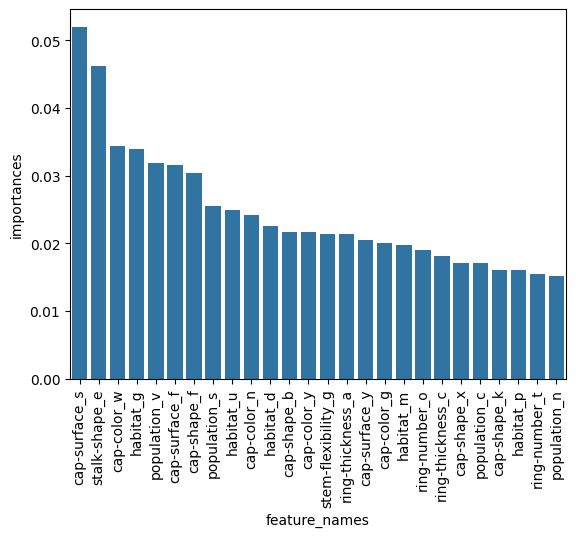

In [26]:
sns.barplot(importance_df[mask], x="feature", y="importance_rate")

plt.xlabel("feature_names")
plt.ylabel("importances")
plt.xticks(rotation=90)

plt.show()

**Вывод:**  

- наиболее важные признаки для модели: форма ножки `(stalk-shape e)`, поверхность `(cap-surface f, s)` и цвет `(cap-color w, n, y)` шляпки, среда обитания `(habitat g, u, d)`
- результат согласуется с тепловой картой, так как признаки, имеющие не нулевую корреляцию с целевой переменной, входят в топ по `importance_rate`

### Попытка улучшить результат, используя нативные категории и встроенный подбор средствами `CatBoost`

In [27]:
X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val,
    test_size=0.5,
    random_state=42,
    stratify=y_test_val,
)

features_col = X.columns.tolist()

train_pool = cb.Pool(
    data=X_train,
    label=y_train,
    cat_features=features_col,
)

valid_pool = cb.Pool(
    data=X_val,
    label=y_val,
    cat_features=features_col,
)

test_pool = cb.Pool(
    data=X_test,
    label=y_test,
    cat_features=features_col,
)

In [28]:
model = cb.CatBoostClassifier(
    eval_metric="Recall",
    random_seed=42,
    verbose=False,
)

features_col_ind = list(range(len(features_col)))

selected_features = model.select_features(
    X=train_pool,
    eval_set=valid_pool,
    features_for_select=features_col_ind,
    num_features_to_select=9,
    steps=3,
    verbose=False,
    plot=True,
)

selected_features

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.050311
Step #1 out of 3

bestTest = 0.9411764706
bestIteration = 954

Shrink model to first 955 iterations.
Feature #2 eliminated
Step #2 out of 3

bestTest = 0.9462915601
bestIteration = 665

Shrink model to first 666 iterations.
Feature #7 eliminated
Feature #1 eliminated
Step #3 out of 3

bestTest = 0.9590792839
bestIteration = 1

Shrink model to first 2 iterations.
Feature #0 eliminated
Train final model

bestTest = 0.9514066496
bestIteration = 924

Shrink model to first 925 iterations.


{'selected_features': [3, 4, 5, 6, 8, 9, 10, 11, 12],
 'eliminated_features_names': ['stem-flexibility',
  'gill-attachment',
  'spore-pattern',
  'cap-texture'],
 'loss_graph': {'main_indices': [0, 1, 3, 4],
  'removed_features_count': [0, 1, 2, 3, 4],
  'loss_values': [0.08476645092299848,
   0.08087926505968425,
   0.13451670702813534,
   0.539841151606173,
   0.07960381108726466]},
 'eliminated_features': [2, 7, 1, 0],
 'selected_features_names': ['ring-thickness',
  'cap-shape',
  'cap-surface',
  'cap-color',
  'stalk-shape',
  'veil-color',
  'ring-number',
  'population',
  'habitat']}

In [29]:
selected_cols = selected_features["selected_features_names"]

train_pool_selected = cb.Pool(
    data=X_train[selected_cols],
    label=y_train,
    cat_features=selected_cols,
)

valid_pool_selected = cb.Pool(
    data=X_val[selected_cols],
    label=y_val,
    cat_features=selected_cols,
)

test_pool_selected = cb.Pool(
    data=X_test[selected_cols],
    label=y_test,
    cat_features=selected_cols,
)

model_selected = cb.CatBoostClassifier(
    eval_metric="Recall",
    random_seed=42,
    verbose=False,
)

with timer("Время обучения CatBoost на отобранных признаках"):
    model_selected.fit(
        X=train_pool_selected,
        eval_set=valid_pool_selected,
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False,
    )

with timer("Время предсказания"):
    y_pred = model_selected.predict(test_pool_selected)

Время обучения CatBoost на отобранных признаках: 0.3249 секунд
Время предсказания: 0.0005 секунд


In [30]:
get_classifire_metrics(y_test, y_pred, pos_label="p")

accuracy: 0.9164 
precision: 0.8857 
recall: 0.9490 
f1: 0.9163 



**Вывод:**  

После отбора признаков и без использования кодирования признаков:
- модель стала обучаться быстрее `(2.46 | 0.33)`, предсказание тоже `(0.0016 | 0.0006)`
- самую главную метрику `recall` удалось улучшить `(0.934 | 0.949)`, но общее качество модели значительно ухудшилось: `accuracy (0.955 | 0.916)`, `precision (0.971 | 0.886)`, `f1 (0.952 | 0.916)`

Отбор признаков не привел к значительным улучшениям. Несмотря на ускорение работы и небольшой рост `recall`, общее качество модели значительно упало.